In [1]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy
from tqdm import tqdm

import torch
import matplotlib.pyplot as plt

## Check mnfinder_clean_data cleaned the overlap or not? 

In [11]:
path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/testing/'
files = os.listdir(path)
files = [file for file in files if not file.startswith('.')]
mic_files = [file for file in files if file.endswith('.phenotype_outlines.png')]
nuc_files = [file.replace('.phenotype_outlines.png', '.nuclei-clean.tif') for file in mic_files]
for m,n in zip(mic_files, nuc_files):
    mic_masks = skimage.io.imread(path + m) # here is for mnfinder data
    nuc_masks = skimage.io.imread(path + n)
    
    # print(mic_masks.shape)
    # print(nuc_masks.shape)
    mask = np.mean(mic_masks, axis=2) > 0
    edge = skimage.filters.sobel(mask) > 0
    full_mic = mask + edge
    overlap = np.logical_and(full_mic, nuc_masks)
    print(np.unique(overlap))
    # print(np.unique(nuc_masks))

[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]
[False]


# Filter BBBC039 with micronuclei annotation

In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy

import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

- create histogram of input images, check the size distribution!
  

(520, 696, 4)


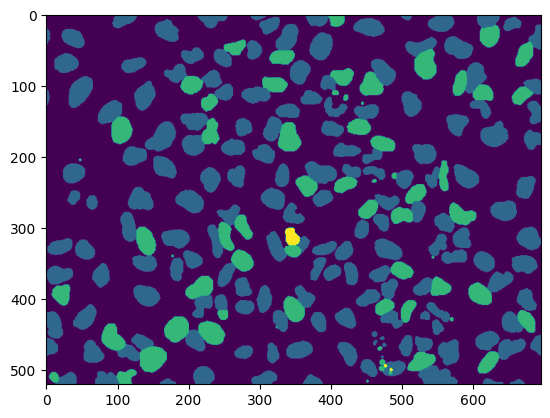

In [31]:
mask_path = '/scr/yren/BBBC039/masks/'
masks = os.listdir(mask_path)
masks = [mask for mask in masks if not mask.startswith('.')]
im = skimage.io.imread(mask_path + 'IXMtest_K12_s7_w12A7857A5-3C92-4A08-8E81-2CA8A99F67AE.png')
print(im.shape)
plt.imshow(im[:,:,0])
im = im[:,:,0]

16


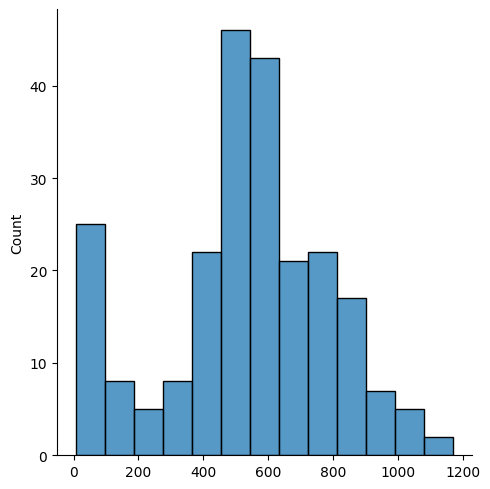

In [32]:
areas = []
labels = skimage.morphology.label(im)
for i in range(1, len(np.unique(labels))):
    a = np.sum(labels == i)
    if a == 99:
        print(i)
    areas.append(int(a))
sns.displot(areas)

In [39]:
print(sorted(areas))

[12, 16, 19, 21, 21, 26, 31, 87, 99, 143, 150, 161, 178, 210, 268, 294, 312, 337, 372, 392, 409, 409, 413, 431, 435, 441, 459, 462, 469, 475, 481, 484, 501, 501, 505, 507, 511, 518, 523, 526, 535, 535, 549, 552, 552, 557, 561, 564, 566, 571, 572, 576, 581, 583, 584, 586, 592, 595, 596, 602, 607, 607, 631, 637, 637, 638, 644, 645, 646, 651, 653, 654, 655, 656, 656, 671, 671, 672, 679, 679, 691, 695, 708, 709, 710, 715, 717, 723, 728, 739, 744, 744, 744, 753, 769, 772, 792, 792, 795, 797, 799, 814, 818, 821, 822, 837, 841, 859, 863, 866, 879, 882, 883, 896, 923, 927, 954, 963, 984, 1043, 1160, 1204, 1212, 1326, 1398, 1418, 1560, 1700]


In [15]:
print(im.shape)

(520, 696)


324 551
[[  0 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]
 [127 127 127 127 127 127 127 127 127 127]]


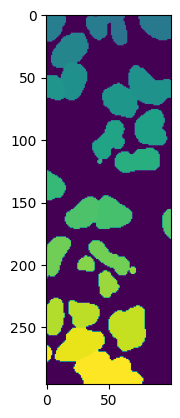

In [33]:
# area of 99 simes to be nuclei instead of micronuclei, below 50 has micronuclei makes more sense.
ys, xs = np.where(labels == 127)
y,x = int(np.mean(ys)), int(np.mean(xs))
print(y,x)
print(labels[y-5:y+5,x-5:x+5])
plt.imshow(labels[y-100:,x-50:x+50])

## Iterate through all images, define which should be discarded. Seperate BBBC039 nuclei and micronuclei in ground truth, change the suffix too!

- Example

In [97]:
im = skimage.io.imread(mask_path + 'IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4C949B3B.png')
im = np.mean(im, axis=2) # dont use this
np.unique(im)

array([63.75, 64.  , 64.25, 64.5 ])

In [12]:
mask_path = '/scr/yren/BBBC039/masks/'
masks = os.listdir(mask_path)
masks = [mask for mask in masks if not mask.startswith('.')]
im = skimage.io.imread(mask_path + 'IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4C949B3B.png')

print(im.shape)
# plt.imshow(im[:,:,0])
im = im[:,:,0] # dont use np.mean, background values will be averaged which results in value > 0, cant seperate.
# im = np.mean(im, axis=2)

MICRON_AREA_THRESHOLD = 50
labels = skimage.morphology.label(im)
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD: # 50
        micron_labels.append(i)
        
print(micron_labels)
micro_mask = np.zeros_like(im)
for i in micron_labels:
    micro_mask += (labels == i)
nuclei_mask = (labels > 0) ^ (micro_mask > 0) # xor only works on binary case

(520, 696, 4)
[15, 39, 45, 98, 101, 102, 120]


In [13]:
np.unique(im)

array([0, 1, 2, 3], dtype=uint8)

In [14]:
np.unique(nuclei_mask)

array([False,  True])

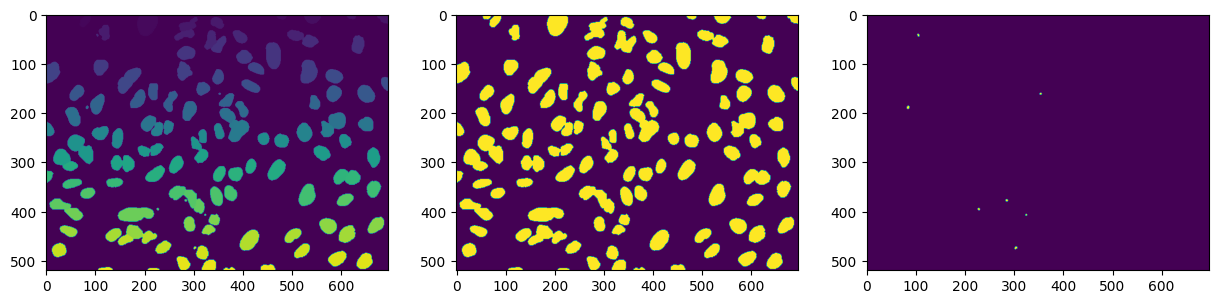

In [15]:
fig, axs = plt.subplots(1,3, figsize=(15,15))
axs[0].imshow(labels)
axs[1].imshow(nuclei_mask)
axs[2].imshow(micro_mask) 

- save nuclei mask as nuclei-clean.tif, and micronuclei as phenotype_outlines.png, no channel information (grayscale), remember to rescale

[False  True]


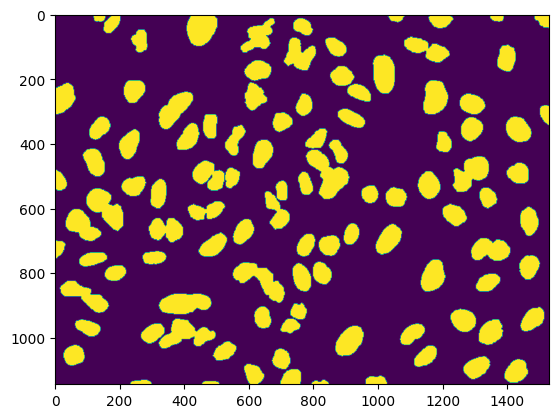

In [16]:
nuc = skimage.transform.rescale(nuclei_mask, 2.2)
print(np.unique(nuc))
plt.imshow(nuc)

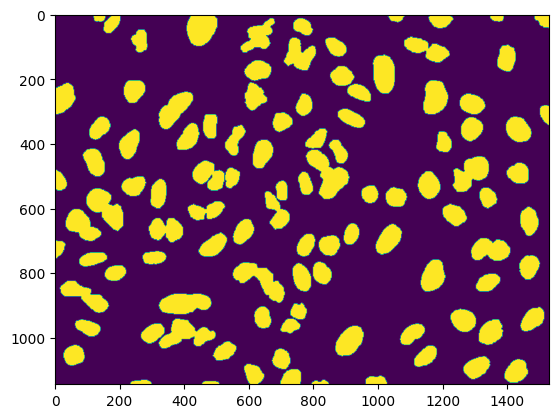

In [17]:
im2 = skimage.io.imread('/scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4C949B3B.nuclei.tif')
plt.imshow(im2)

In [4]:
scale = round((14/4.25)/(20/13.1), 1)
scale

2.2

In [66]:
mat = np.random.randint(0, 2, size=(10, 10))
mat2 = skimage.transform.rescale(mat, 2.2)
print(np.unique(mat))
print(np.unique(mat2))

[0 1]
[0.00000000e+00 1.79206971e-21 1.79206971e-21 2.68810456e-21
 2.68810456e-21 3.58413941e-21 3.58413941e-21 3.58413941e-21
 3.58413941e-21 4.48017427e-21 4.48017427e-21 4.48017427e-21
 5.37620912e-21 6.27224397e-21 6.27224397e-21 7.16827883e-21
 7.16827883e-21 7.16827883e-21 8.06431368e-21 8.06431368e-21
 8.06431368e-21 8.06431368e-21 8.96034853e-21 8.96034853e-21
 9.85638339e-21 9.85638339e-21 1.07524182e-20 1.07524182e-20
 1.07524182e-20 1.07524182e-20 1.07524182e-20 1.34405228e-20
 1.43365577e-20 1.43365577e-20 1.43365577e-20 1.61286274e-20
 1.61286274e-20 1.61286274e-20 1.61286274e-20 1.79206971e-20
 1.79206971e-20 1.88167319e-20 1.97127668e-20 1.97127668e-20
 2.15048365e-20 2.15048365e-20 2.15048365e-20 2.15048365e-20
 2.15048365e-20 2.15048365e-20 2.24008713e-20 2.41929410e-20
 2.41929410e-20 2.50889759e-20 2.50889759e-20 2.59850107e-20
 2.68810456e-20 2.68810456e-20 2.68810456e-20 2.68810456e-20
 2.68810456e-20 2.77770805e-20 2.86731153e-20 2.86731153e-20
 2.86731153e-20 2.

In [ ]:
print(im.shape)
im2 = skimage.transform.rescale(im, scale=scale)
print(im2.shape)

(520, 696)
(520, 696, 4)
(1144, 1531)


# Process and Rescale BBBC039 images, save as labeled matrices

In [20]:
MICRON_AREA_THRESHOLD = 50 # reasonable threshold based
scale = round((14/4.25)/(20/13.1), 1) # 2.2

mask_path = '/scr/yren/BBBC039/masks/'
image_path = '/scr/yren/BBBC039/images/'
mask_save_path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'
image_save_path = '/scr/yren/BBBC039_cleaned_rescaled/images/'

masks = os.listdir(mask_path)
masks = [mask for mask in masks if not mask.startswith('.')]
masks = [mask for mask in masks if mask.endswith('.png')]
# print(len(masks))

# min_areas = []
for mask_name in tqdm(masks):
    mask = skimage.io.imread(mask_path + mask_name)
    mask = mask[:,:,0]
    areas = []
    labels = skimage.morphology.label(mask)
    micron_labels = []
    for i in range(1, len(np.unique(labels))):
        a = np.sum(labels == i)
        if a < MICRON_AREA_THRESHOLD:
            micron_labels.append(i)
        areas.append(int(a))
        
    if len(areas) > 0: # there are few images that only has background...
        if min(areas) <= MICRON_AREA_THRESHOLD: # has micronuclei
            # seperate nuclei & micronuclei channel
            micro_mask = np.zeros_like(mask)
            for j in micron_labels:
                micro_mask += (labels == j)
            nuclei_mask = (labels > 0) ^ (micro_mask > 0)
            
            # rescale the input, nuclei mask, micronuclei mask
            imid = mask_name.split('.')[0]
            im = skimage.io.imread(image_path + imid + '.tif')
            im = skimage.transform.rescale(im, scale=scale)
            # print(im.shape)
            # print(nuclei_mask.shape)
            # print(micro_mask.shape)
            
            # if input is boolean, then output is also boolean.
            nuclei_mask = skimage.transform.rescale(nuclei_mask, scale=scale)
            micro_mask = skimage.transform.rescale(micro_mask > 0, scale=scale)
            
            # convert to boolean
            micro_mask = micro_mask > 0
            nuclei_mask = nuclei_mask > 0
            
            # convert to labeled matrices
            micro_labels = skimage.morphology.label(micro_mask)
            micro_labels = np.asarray(micro_labels, dtype='uint16') # for saving, avoid overflow
            
            nuclei_labels = skimage.morphology.label(nuclei_mask)
            nuclei_labels = np.asarray(nuclei_labels, dtype='uint16') # for saving, avoid overflow
            
            # save all of the three and add suffix
            skimage.io.imsave(image_save_path + imid + '.phenotype.tif', im)
            skimage.io.imsave(mask_save_path + imid + '.nuclei.tif', nuclei_labels)
            skimage.io.imsave(mask_save_path + imid + '.phenotype_outlines.png', micro_labels)


  0%|          | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_3895847/2896510492.py:59: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/images/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype.tif is a low contrast image
  skimage.io.imsave(image_save_path + imid + '.phenotype.tif', im)
/tmp/ipykernel_3895847/2896510492.py:60: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei.tif is a low contrast image
  skimage.io.imsave(mask_save_path + imid + '.nuclei.tif', nuclei_labels)
/tmp/ipykernel_3895847/2896510492.py:61: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(mask_save_path + imid + '.phenotype_outlines.png', micro_labels)
  0%|          | 1/200 [00:00<00:42,  4.68it/s]/tmp/ipykernel_3895847/2896510492.py:59: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/images/IXMtest_N12_s7_w166EF3FA

# Remove touch between BBBC039 nuclei and micronuclei in ground truth

- change nuclei.tif suffix to nuclei-clean.tif

In [21]:
mask_save_path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'

masks = os.listdir(mask_save_path)
mask_files = [mask for mask in masks if not mask.startswith('.')]

mic_masks = [mask for mask in mask_files if mask.endswith('phenotype_outlines.png')]
nuc_masks = [mask for mask in mask_files if mask.endswith('nuclei.tif')]

micron_files = [mask_save_path + x for x in mic_masks]
nuclei_files = [mask_save_path + x for x in nuc_masks]

print(micron_files[0])
print(nuclei_files[0])

/scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype_outlines.png
/scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei.tif


In [22]:
total_overlap = 0
for m, n in zip(micron_files, nuclei_files):
    print(n.split("/")[-1])
    
    # Load micronuclei and nuclei masks
    mic_masks = skimage.io.imread(m)
    nuc_masks = skimage.io.imread(n)

    # Find overlaps and remove them
    overlap = np.logical_and(mic_masks, nuc_masks)
    print("Overlap:",np.sum(overlap))
    
    clean_nuclei = (nuc_masks>0) ^ overlap
    clean_labels = skimage.morphology.label(clean_nuclei)
    clean_labels = np.asarray(clean_labels, dtype="uint16")

    # Save result
    skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)

IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei.tif
Overlap: 0
IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE.nuclei.tif
Overlap: 0
IXMtest_D06_s8_w1BE84C8EF-4CD0-4B56-8267-4E662F57AC25.nuclei.tif
Overlap: 0
IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F75808E2321.nuclei.tif
Overlap: 0
IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27990714B.nuclei.tif
Overlap: 0
IXMtest_K17_s5_w1BB3AD9D7-3A85-458C-AB1C-07A816C2C203.nuclei.tif
Overlap: 0
IXMtest_H07_s2_w1D8F30687-16A2-4A0D-BDD5-377257089055.nuclei.tif
Overlap: 0
IXMtest_G16_s3_w1B4690283-D75E-4DFB-92B0-29419E8292C6.nuclei.tif
Overlap: 0


/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_D06_s8_w1BE84C8EF-4CD0-4B56-8267-4E662F57AC25.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F75808E2321.nuclei-clean.tif is a low contrast image


IXMtest_P09_s4_w11E382363-8C26-4A73-9D8A-8193D66E5785.nuclei.tif
Overlap: 0
IXMtest_F12_s9_w1CD127D58-4641-41D3-88CC-E12B7FE77D78.nuclei.tif
Overlap: 0
IXMtest_B04_s2_w17C6C7F8D-98F7-422B-92CD-EA61EE813325.nuclei.tif
Overlap: 0
IXMtest_J17_s1_w19E7BCD2F-6D7E-4B39-9154-F93E4D539183.nuclei.tif
Overlap: 0
IXMtest_G16_s6_w1C3F175E2-0AF5-401C-AC5C-8E128A237B22.nuclei.tif
Overlap: 0
IXMtest_B23_s1_w152C21D3B-75A9-4FF9-839A-23E6CE19AEEC.nuclei.tif
Overlap: 0
IXMtest_O24_s5_w175443699-7C4C-4E5F-9C5F-57A342CC87DE.nuclei.tif
Overlap: 0
IXMtest_M12_s5_w16D817EFA-C3C9-45DB-AC15-61BB143DEC62.nuclei.tif
Overlap: 0


/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_P09_s4_w11E382363-8C26-4A73-9D8A-8193D66E5785.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_F12_s9_w1CD127D58-4641-41D3-88CC-E12B7FE77D78.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_B04_s2_w17C6C7F8D-98F7-422B-92CD-EA61EE813325.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_J17_s1_w19E7BCD2F-6D7E-4B39-9154-F93E4D539183.nuclei-clean.tif is a low contrast image


IXMtest_C05_s7_w1F71963FB-8F29-41CB-A5F5-07CB9584BBC5.nuclei.tif
Overlap: 0
IXMtest_M23_s8_w118BC311D-A998-4161-8256-22839B2421F2.nuclei.tif
Overlap: 0
IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1.nuclei.tif
Overlap: 0
IXMtest_P15_s8_w1D26A5BC7-CF59-4027-B785-85AD33773609.nuclei.tif
Overlap: 0
IXMtest_N12_s9_w1C98EC3CC-2F8E-4761-A21A-EBF14469AD40.nuclei.tif
Overlap: 0
IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB.nuclei.tif
Overlap: 0
IXMtest_H18_s7_w1D78A9181-AF11-4219-9C1E-2DB2684E948E.nuclei.tif
Overlap: 0
IXMtest_G10_s3_w1C1257E17-1DBA-4619-B06E-D6DBB8A53088.nuclei.tif
Overlap: 0


...

/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_L03_s2_w1AC4550E2-F824-4A58-9CC5-952AD9ECE76A.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_L17_s1_w1DDC627E5-ADF1-441C-A437-D1D91CC0D498.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_O07_s2_w148B3D2F0-D4D6-4F1A-88D3-F18574F52153.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-022806CF6D42.nuclei-clean.tif is a low contrast image


IXMtest_G12_s6_w16850371E-A405-4D73-9816-F5F68F885D38.nuclei.tif
Overlap: 0
IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D.nuclei.tif
Overlap: 0
IXMtest_K03_s5_w1DC4CE558-042C-482E-8CAE-FCCB57AA9A55.nuclei.tif
Overlap: 0
IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168AA755527.nuclei.tif
Overlap: 0
IXMtest_G18_s9_w17F495AF2-03D2-4683-BD37-56887F4A3A84.nuclei.tif
Overlap: 0
IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75.nuclei.tif
Overlap: 0
IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2CEA6BE2.nuclei.tif
Overlap: 0
IXMtest_P19_s6_w10EBAD15B-2822-48B9-B9C8-4DF5D80AB940.nuclei.tif


/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_G12_s6_w16850371E-A405-4D73-9816-F5F68F885D38.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_A15_s5_w1825174D4-ED30-490C-9635-6196417D6C9D.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_K03_s5_w1DC4CE558-042C-482E-8CAE-FCCB57AA9A55.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168AA755527.nuclei-clean.tif is a low contrast image


Overlap: 0
IXMtest_I18_s3_w1544C8B7A-E092-4F9D-B8D3-C489638D770F.nuclei.tif
Overlap: 0
IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC35BAE513.nuclei.tif
Overlap: 0
IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-5681452CCD1D.nuclei.tif
Overlap: 0
IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B61FF39F7.nuclei.tif
Overlap: 0
IXMtest_M12_s7_w193E9BA0F-274A-4EE8-A0F0-6A58471A333A.nuclei.tif
Overlap: 0
IXMtest_I11_s6_w1B2DC04C7-2D7D-45C6-9DC2-66D8605FBE63.nuclei.tif
Overlap: 0
IXMtest_H11_s6_w19DF4E879-8DE4-45D6-840B-305BDDB27076.nuclei.tif
Overlap: 0


/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_I18_s3_w1544C8B7A-E092-4F9D-B8D3-C489638D770F.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC35BAE513.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-5681452CCD1D.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(n.replace(".nuclei.tif",".nuclei-clean.tif"), clean_labels)
/tmp/ipykernel_3895847/3330594378.py:18: UserWarning: /scr/yren/BBBC039_cleaned_rescaled/masks/IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B61FF39F7.nuclei-clean.tif is a low contrast image


- check number of files

In [23]:
mask_save_path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'
image_save_path = '/scr/yren/BBBC039_cleaned_rescaled/images/'

masks = os.listdir(mask_save_path)
images = os.listdir(image_save_path)

mask_files = [mask for mask in masks if not mask.startswith('.')]
image_files = [image for image in images if not image.startswith('.')]

inputs = [image for image in image_files if image.endswith('phenotype.tif')]
nuc_masks = [mask for mask in mask_files if mask.endswith('nuclei-clean.tif')]
mic_masks = [mask for mask in mask_files if mask.endswith('phenotype_outlines.png')]

print(len(inputs), len(nuc_masks), len(mic_masks))

192 192 192


- check dimensions

In [24]:
im = skimage.io.imread(image_save_path + inputs[0])
nuc = skimage.io.imread(mask_save_path + nuc_masks[0])
mic = skimage.io.imread(mask_save_path + mic_masks[0])

print(im.shape)
print(nuc.shape)
print(mic.shape)

(1144, 1531)
(1144, 1531)
(1144, 1531)


## Check every image in masks folder if there is any overlap

In [25]:
path = '/scr/yren/BBBC039_cleaned_rescaled/masks/'
files = os.listdir(path)
files = [file for file in files if not file.startswith('.')]
mic_files = [file for file in files if file.endswith('.phenotype_outlines.png')]
nuc_files = [file.replace('.phenotype_outlines.png', '.nuclei-clean.tif') for file in mic_files]
for m,n in zip(mic_files, nuc_files):
    mic_masks = skimage.io.imread(path + m) # here is for mnfinder data
    nuc_masks = skimage.io.imread(path + n)

    overlap = np.logical_and(mic_masks, nuc_masks)
    
    if (True in np.unique(overlap)):
        print('Overlaps found!')
    else:
        print('Overlaps not found!')

Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!
Overlaps not found!


# Process mnfinder validation data

- reformat data

In [17]:
from tqdm import tqdm

In [36]:
test_path = '/scr/yren/mnfinder_validation'
output_test_path = '/scr/yren/mnfinder_new_test_data/'
os.makedirs(output_test_path, exist_ok=True)
for folder in tqdm(os.listdir(test_path)):
    if not '.DS_Store' in folder:
        for phenotype in os.listdir(f'{test_path}/{folder}/images/'):
            filename = phenotype.split('.')[0]
            filename = filename.replace(' ', '_')
            source = f'{test_path}/{folder}/images'
            destination = f'{output_test_path}/{folder}-{filename}.phenotype.tif'

            im = skimage.io.imread(f'{source}/{phenotype}')
            skimage.io.imsave(destination, im)

        for mn_mask in os.listdir(f'{test_path}/{folder}/mn_masks/'):
            filename = mn_mask.split('.')[0]
            filename = filename.replace(' ', '_')
            source = f'{test_path}/{folder}/mn_masks'
            destination = f'{output_test_path}/{folder}-{filename}.phenotype_outlines.png'

            im = skimage.io.imread(f'{source}/{mn_mask}')
            skimage.io.imsave(destination, im)

        for n_mask in os.listdir(f'{test_path}/{folder}/nucleus_masks/'):
            filename = n_mask.split('.')[0]
            filename = filename.replace(' ', '_')
            source = f'{test_path}/{folder}/nucleus_masks/'
            destination = f'{output_test_path}/{folder}-{filename}.nuclei.tif'
            
            im = skimage.io.imread(f'{source}/{n_mask}')
            skimage.io.imsave(destination, im)

  0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_2956740/648016279.py:13: UserWarning: /scr/yren/mnfinder_new_test_data//2022-05-26_RPE1-2198.phenotype.tif is a low contrast image
  skimage.io.imsave(destination, im)
/tmp/ipykernel_2956740/648016279.py:22: UserWarning: /scr/yren/mnfinder_new_test_data//2022-05-26_RPE1-2198.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(destination, im)
 50%|█████     | 2/4 [00:00<00:00, 16.73it/s]/tmp/ipykernel_2956740/648016279.py:22: UserWarning: /scr/yren/mnfinder_new_test_data//2023-05-31_misc-4.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(destination, im)
/tmp/ipykernel_2956740/648016279.py:22: UserWarning: /scr/yren/mnfinder_new_test_data//2022-10-14_U2OS-1.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(destination, im)
/tmp/ipykernel_2956740/648016279.py:31: UserWarning: /scr/yren/mnfinder_new_test_data//2022-10-14_U2OS-1.nuclei.tif is a low contrast image
  skimage.io.imsave(desti

- remove overlap

In [37]:
im = skimage.io.imread('/scr/yren/mnfinder_new_test_data/2022-05-26_RPE1-2198.phenotype_outlines.png')
im2 = skimage.io.imread('/scr/yren/mnfinder_new_test_data/2022-05-26_RPE1-2198.nuclei.tif')
print(im.shape)
print(im2.shape)

(768, 869, 4)
(768, 869, 4)


# Create metadata file

In [30]:
all_data = pd.DataFrame(columns=['filenames', 'datasets', 'magnification', 'micron'])
# dataset choice: pilot, screen, v3_RPE, v3_HeLa, BBBC039, mnfinder_train, mnfinder_test, mnfinder_validation
# for v3_RPE, v3_HeLa, 1 image for train,val,test respectively.
data_folders = ['dataset_v2', 'dataset_v3', 'BBBC039_cleaned_rescaled', 'mnfinder_clean_data']
screen_imids = ['C2-20X_c0-DAPI-GFP_A1_Tile-17', 
                'C2-20X_c0-DAPI-GFP_A1_Tile-5', 
                'C2-20X_c0-DAPI-GFP_A2_Tile-5', 
                'C2-20X_c0-DAPI-GFP_A3_Tile-6', 
                'C2-20X_c0-DAPI-GFP_B1_Tile-8', 
                'C2-20X_c0-DAPI-GFP_B2_Tile-20',
                'C2-20X_c0-DAPI-GFP_B3_Tile-10', 
                'C2-20X_c0-DAPI-GFP_B3_Tile-16']
all_data
path = '/scr/yren/all_data_micronuclei/'


for folder in data_folders:
    if folder == 'dataset_v2':
        files = os.listdir(path + folder + '/')
        files = [file for file in files if not file.startswith('.')]
        files = [file for file in files if file.endswith('.phenotype.tif')]
        for image in files:
            imid = image.split('.')[0].strip()
            imid = str(imid)
            if (imid in screen_imids):
                row = {'filenames':image, 'datasets':'screen', 'magnification':14, 'micron':4.25}
            else:
                row = {'filenames':image, 'datasets':'pilot', 'magnification':14, 'micron':4.25}
            all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
        
    if folder == 'dataset_v3':
        subfolders = ['HeLa', 'RPE1']
        for subfolder in subfolders:
            if subfolder == 'RPE1':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype_phalloidin.tif')]
                for image in files:
                    row = {'filenames':image.replace('.phenotype_phalloidin.tif', '.phenotype.tif'), 'datasets':subfolder, 'magnification':20, 'micron':6.5}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
            else:
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':subfolder, 'magnification':20, 'micron':6.5}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
    if folder == 'mnfinder_clean_data':
        subfolders = ['training', 'testing', 'validation']
        # remeber to check 40x in the testing subfolder
        for subfolder in subfolders:
            if subfolder == 'testing':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    if '40x' in image:
                        row = {'filenames':image, 'datasets':'mnfinder_test', 'magnification':40, 'micron':13}
                        all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
                    else:
                        row = {'filenames':image, 'datasets':'mnfinder_test', 'magnification':20, 'micron':11}
                        all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
            elif subfolder == 'training':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':'mnfinder_train', 'magnification':20, 'micron':11}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
            elif subfolder == 'validation':
                files = os.listdir(path + folder + '/' + subfolder + '/')
                files = [file for file in files if not file.startswith('.')]
                files = [file for file in files if file.endswith('.phenotype.tif')]
                for image in files:
                    row = {'filenames':image, 'datasets':'mnfinder_validation', 'magnification':20, 'micron':11}
                    all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)
                
    if folder == 'BBBC039_cleaned_rescaled':
        files = os.listdir(path + folder + '/images/')
        files = [file for file in files if not file.startswith('.')]
        files = [file for file in files if file.endswith('.phenotype.tif')]
        for image in files:
            row = {'filenames':image, 'datasets':'BBBC039', 'magnification':20, 'micron':13.1}
            all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)

/tmp/ipykernel_3895847/2518840898.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat([all_data, pd.DataFrame([row])], ignore_index=True)


- stratified sampling, and assign train/validation/test as last column (for each datasets)

In [31]:
# all_data[all_data['datasets'] == 'mnfinder_test']
all_data

,filenames,datasets,magnification,micron
0,20X_c0-DAPI_A1_Tile-190.phenotype.tif,pilot,14,4.25
1,C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif,screen,14,4.25
2,C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype.tif,screen,14,4.25
3,C2-20X_c0-DAPI-GFP_B3_Tile-16.phenotype.tif,screen,14,4.25
4,20X_c0-DAPI_A1_Tile-50.phenotype.tif,pilot,14,4.25
...,...,...,...,...
260,2023-05-31_misc-MCC13_rfpcyto_w1cDAPI_s47.phen...,mnfinder_test,20,11.00
261,2022-10-14_U2OS-4.phenotype.tif,mnfinder_test,20,11.00
262,2022-05-26_RPE1-2198.phenotype.tif,mnfinder_validation,20,11.00
263,2022-10-14_U2OS-1.phenotype.tif,mnfinder_validation,20,11.00


In [32]:
data_without_mnfinder_v3 = all_data[all_data['datasets'].isin(['pilot', 'screen', 'BBBC039'])]
data_v3 = all_data[all_data['datasets'].isin(['HeLa', 'RPE1'])]
data_mnfinder = all_data[~all_data['datasets'].isin(['pilot', 'screen', 'BBBC039', 'HeLa', 'RPE1'])]
data_mnfinder['split'] = data_mnfinder['datasets'].apply(lambda x: x.split('_')[-1])

/tmp/ipykernel_3895847/2647424196.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_mnfinder['split'] = data_mnfinder['datasets'].apply(lambda x: x.split('_')[-1])


In [33]:
split = ['train', 'validation', 'test'] * 2
data_v3['split'] = split
data_v3

/tmp/ipykernel_3895847/1814804534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_v3['split'] = split


,filenames,datasets,magnification,micron,split
18,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
19,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
20,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
21,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
22,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
23,C1-20X_c0_phalloidin_C3_Tile-44.phenotype.tif,RPE1,20,6.5,test


In [34]:
data_mnfinder.head()

,filenames,datasets,magnification,micron,split
216,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
217,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
218,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
219,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
220,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train


In [35]:
data_without_v2_039 = pd.concat([data_mnfinder, data_v3], ignore_index=True)
data_without_v2_039

,filenames,datasets,magnification,micron,split
0,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
1,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
2,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
3,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
4,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train
5,2022-03-18_RPE1-4.phenotype.tif,mnfinder_train,20,11.0,train
6,2022-05-26_RPE1-2.phenotype.tif,mnfinder_train,20,11.0,train
7,2022-05-26_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
8,2023-05-31_misc-10.phenotype.tif,mnfinder_train,20,11.0,train
9,2023-05-31_misc-11.phenotype.tif,mnfinder_train,20,11.0,train


## Stratified sampling for pilot & screen

In [36]:
print(data_without_mnfinder_v3.shape)

(210, 4)


In [50]:
from sklearn.model_selection import train_test_split

pilot_screen = all_data[all_data['datasets'].isin(['pilot', 'screen'])]
X_train, X_tmp = train_test_split(pilot_screen, test_size=0.3, stratify=pilot_screen['datasets'])

In [51]:
X_test, X_validation = train_test_split(X_tmp, test_size=0.5, stratify=X_tmp['datasets'])

In [52]:
print(X_train.shape)
print(X_validation.shape)
print(X_test.shape)

(12, 4)
(3, 4)
(3, 4)


In [53]:
X_train['split'] = 'train'
X_validation['split'] = 'validation'
X_test['split'] = 'test'

### create split for BBBBC039 data

In [59]:
with open('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/metadata/training.txt', 'r') as file:
    lines = file.readlines()
training = [line.strip().split('.')[0] for line in lines]

with open('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/metadata/validation.txt', 'r') as file:
    lines = file.readlines()
validation = [line.strip().split('.')[0] for line in lines]

with open('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/metadata/test.txt', 'r') as file:
    lines = file.readlines()
test = [line.strip().split('.')[0] for line in lines]


In [74]:
data_bbbc039 = all_data[all_data.datasets == 'BBBC039']
data_bbbc039['split'] = 'none'

# Convert lists to sets for efficient lookup
training_set = set(training)
validation_set = set(validation)
test_set = set(test)

# Assign 'split' values using vectorized operations
data_bbbc039['split'] = data_bbbc039['filenames'].apply(lambda x: 
    'train' if x.split('.')[0] in training_set else 
    'validation' if x.split('.')[0] in validation_set else 
    'test' if x.split('.')[0] in test_set else 
    'none'
)

/tmp/ipykernel_3895847/1159607307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bbbc039['split'] = 'none'
/tmp/ipykernel_3895847/1159607307.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_bbbc039['split'] = data_bbbc039['filenames'].apply(lambda x:


In [75]:
data_bbbc039

,filenames,datasets,magnification,micron,split
24,IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108D...,BBBC039,20,13.1,test
25,IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1...,BBBC039,20,13.1,validation
26,IXMtest_D06_s8_w1BE84C8EF-4CD0-4B56-8267-4E662...,BBBC039,20,13.1,test
27,IXMtest_I16_s9_w1582FD22A-5270-4FDC-868F-5F758...,BBBC039,20,13.1,validation
28,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,BBBC039,20,13.1,train
...,...,...,...,...,...
211,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,20,13.1,train
212,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,20,13.1,train
213,IXMtest_M12_s7_w193E9BA0F-274A-4EE8-A0F0-6A584...,BBBC039,20,13.1,test
214,IXMtest_I11_s6_w1B2DC04C7-2D7D-45C6-9DC2-66D86...,BBBC039,20,13.1,validation


In [76]:
# data_without_v2_039
final_data = pd.concat([data_without_v2_039, X_train, X_validation, X_test, data_bbbc039], ignore_index=True)

In [77]:
print(final_data.shape)
final_data.head()

(265, 5)


,filenames,datasets,magnification,micron,split
0,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
1,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
2,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
3,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
4,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train


In [105]:
print(final_data[final_data.split == 'train'].shape)
print(final_data[final_data.split == 'validation'].shape)
print(final_data[final_data.split == 'test'].shape)

(141, 5)
(55, 5)
(69, 5)


In [78]:
final_data.to_csv('/scr/yren/all_data_micronuclei/metadata.csv', index=False)

# Process dataset v2 and v3 (HeLa, RPE1), v3 has been scaled already in scale_aligned_dataset_v2_v3

In [3]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
print(metadata.shape)

(265, 5)


In [4]:
path = '/scr/yren/all_data_micronuclei/scale_aligned_dataset_v2_v3/'
im = skimage.io.imread(path + 'C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype_outlines.png')
print(im.shape)

(2960, 2960, 4)


In [5]:
data_v2_v3 = metadata[metadata['datasets'].isin(['pilot', 'screen', 'HeLa', 'RPE1'])]
print(data_v2_v3.shape)

path = '/scr/yren/all_data_micronuclei/scale_aligned_dataset_v2_v3/'

for row in range(data_v2_v3.shape[0]):
    # convert mask and save
    imid = data_v2_v3.iloc[row]['filenames'].split('.')[0]
    im = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    edge = im[:,:,0] > 0
    mask = scipy.ndimage.binary_fill_holes(edge) ^ edge
    mask = mask + edge
    
    if data_v2_v3.iloc[row]['split'] == 'train':
        save_path = '/scr/yren/all_data_micronuclei/train/'
    elif data_v2_v3.iloc[row]['split'] == 'validation':
        save_path = '/scr/yren/all_data_micronuclei/validation/'
    elif data_v2_v3.iloc[row]['split'] == 'test':
        save_path = '/scr/yren/all_data_micronuclei/test/'
        
    labels = skimage.morphology.label(mask)
    labels = np.asarray(labels, dtype='uint16')
    
    # save micronuclei mask
    skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', labels)
    # copy nuclei mask
    nuclei_mask = skimage.io.imread(path + imid + '.nuclei-clean.tif')
    skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)

    # copy phenotype input
    phenotype = skimage.io.imread(path + imid + '.phenotype.tif')
    skimage.io.imsave(save_path + imid + '.phenotype.tif', phenotype)

    
   

(24, 5)


/tmp/ipykernel_3931321/4289603130.py:25: UserWarning: /scr/yren/all_data_micronuclei/train/C1-20X_c0_B3_Tile-5.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', labels)
/tmp/ipykernel_3931321/4289603130.py:28: UserWarning: /scr/yren/all_data_micronuclei/train/C1-20X_c0_B3_Tile-5.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)
/tmp/ipykernel_3931321/4289603130.py:25: UserWarning: /scr/yren/all_data_micronuclei/validation/C1-20X_c0_B3_Tile-24.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', labels)
/tmp/ipykernel_3931321/4289603130.py:28: UserWarning: /scr/yren/all_data_micronuclei/validation/C1-20X_c0_B3_Tile-24.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)
/tmp/ipykernel_3931321/4289603130.py:25: UserWarning: /scr/yren/all_data_m

In [95]:
data_v2_v3[data_v2_v3['split']=='train'].shape

(14, 5)

# Process MNFinder Train/Val/Test data

In [6]:
np.unique(metadata['datasets'])

array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype=object)

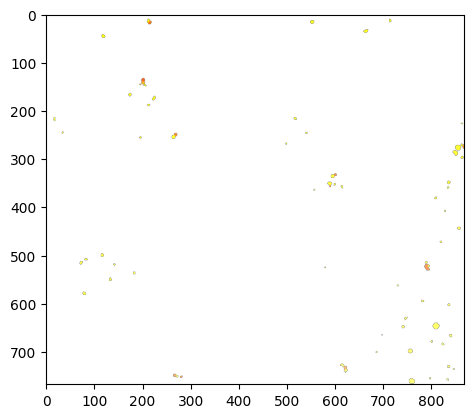

In [7]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/mnfinder_clean_data/validation/2022-10-14_U2OS-1.phenotype_outlines.png')
im2 = np.mean(im, axis=2) > 0
plt.imshow(im)

In [30]:
(14/4.25)/(40/13)

1.0705882352941176

In [8]:
data_mnfinder = metadata[metadata['datasets'].isin(['mnfinder_train', 'mnfinder_validation', 'mnfinder_test'])]

for row in range(data_mnfinder.shape[0]):
    # rescale input, nuclei & micronuclei masks
    scale = round((14/4.25)/(data_mnfinder.iloc[row]['magnification']/data_mnfinder.iloc[row]['micron']), 1)
    # print(scale)
    
    if data_mnfinder.iloc[row]['split'] == 'train':
        path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/training/'
        save_path = '/scr/yren/all_data_micronuclei/train/'
    elif data_mnfinder.iloc[row]['split'] == 'validation':
        path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/validation/'
        save_path = '/scr/yren/all_data_micronuclei/validation/'
    elif data_mnfinder.iloc[row]['split'] == 'test':
        path = '/scr/yren/all_data_micronuclei/mnfinder_clean_data/testing/'
        save_path = '/scr/yren/all_data_micronuclei/test/'
    
    imid = data_mnfinder.iloc[row]['filenames'].split('.')[0]
    
    # process micronuclei mask
    micro_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    micro_mask = np.mean(micro_mask, axis=2) > 0
    micro_mask = skimage.transform.rescale(micro_mask, scale=scale)
    micro_labels = skimage.morphology.label(micro_mask)
    micro_labels = np.asarray(micro_labels, dtype='uint16')
    skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', micro_mask)
    
    # process nuclei mask
    nuclei_mask = skimage.io.imread(path + imid + '.nuclei-clean.tif')
    nuclei_mask = nuclei_mask > 0 # convert to boolean
    nuclei_mask = skimage.transform.rescale(nuclei_mask, scale=scale)
    nuclei_labels = skimage.morphology.label(nuclei_mask)
    nuclei_labels = np.asarray(nuclei_labels, dtype='uint16')
    skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)
    
    # process input images
    input = skimage.io.imread(path + imid + '.phenotype.tif')
    input = skimage.transform.rescale(input, scale=scale)
    skimage.io.imsave(save_path + imid + '.phenotype.tif', input)
    # print(input.shape)

/tmp/ipykernel_3931321/1853856598.py:26: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-3.phenotype_outlines.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', micro_mask)
/tmp/ipykernel_3931321/1853856598.py:26: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-3.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(save_path + imid + '.phenotype_outlines.png', micro_mask)
/tmp/ipykernel_3931321/1853856598.py:34: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE1-3.nuclei-clean.tif is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  skimage.io.imsave(save_path + imid + '.nuclei-clean.tif', nuclei_mask)
/tmp/ipykernel_3931321/1853856598.py:26: UserWarning: /scr/yren/all_data_micronuclei/train/2022-05-27_RPE

In [9]:
sub = metadata[~metadata['datasets'].isin(['BBBC039'])]
sub = sub[sub['split'].isin(['test'])]
sub.shape

(21, 5)

# Read and Resave, BBBC039_clean data has been rescaled (dont use shutil, will corrupt data)

In [50]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/masks/IXMtest_P24_s9_w13AC6C03C-E8D7-4A23-B649-514BB4052F52.phenotype_outlines.png')
print(im.shape)
# plt.imshow(im)

(1144, 1531)


In [57]:
501/3

167.0

In [63]:
metadata[metadata['split']=='validation'].shape

(35, 6)

In [10]:
data_bbbc039 = metadata[metadata['datasets'].isin(['BBBC039'])]
data_bbbc039

for row in range(0, data_bbbc039.shape[0]):
    imid = data_bbbc039.iloc[row]['filenames'].split('.')[0]
    image_path = '/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/images/'
    mask_path = '/scr/yren/all_data_micronuclei/BBBC039_cleaned_rescaled/masks/'
    
    im_src = image_path + imid + '.phenotype.tif'
    im_dst = f'/scr/yren/all_data_micronuclei/{data_bbbc039.iloc[row]['split']}/' + imid + '.phenotype.tif'

    nuclei_src =  mask_path + imid + '.nuclei-clean.tif'
    nuclei_dst = f'/scr/yren/all_data_micronuclei/{data_bbbc039.iloc[row]['split']}/' + imid + '.nuclei-clean.tif'
    
    micron_src =  mask_path + imid + '.phenotype_outlines.png'
    micron_dst = f'/scr/yren/all_data_micronuclei/{data_bbbc039.iloc[row]['split']}/' + imid + '.phenotype_outlines.png'
    
    im = skimage.io.imread(im_src)
    skimage.io.imsave(im_dst, im)
    
    nuclei_mask = skimage.io.imread(nuclei_src)
    skimage.io.imsave(nuclei_dst, nuclei_mask)
    
    micron_mask = skimage.io.imread(micron_src)
    skimage.io.imsave(micron_dst, micron_mask)
    

/tmp/ipykernel_3931321/1024847520.py:19: UserWarning: /scr/yren/all_data_micronuclei/test/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype.tif is a low contrast image
  skimage.io.imsave(im_dst, im)
/tmp/ipykernel_3931321/1024847520.py:22: UserWarning: /scr/yren/all_data_micronuclei/test/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.nuclei-clean.tif is a low contrast image
  skimage.io.imsave(nuclei_dst, nuclei_mask)
/tmp/ipykernel_3931321/1024847520.py:25: UserWarning: /scr/yren/all_data_micronuclei/test/IXMtest_D20_s3_w19D371AF3-0189-48A3-AF3B-D108DE6A017F.phenotype_outlines.png is a low contrast image
  skimage.io.imsave(micron_dst, micron_mask)
/tmp/ipykernel_3931321/1024847520.py:19: UserWarning: /scr/yren/all_data_micronuclei/validation/IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE.phenotype.tif is a low contrast image
  skimage.io.imsave(im_dst, im)
/tmp/ipykernel_3931321/1024847520.py:22: UserWarning: /scr/yren/all_data_micronuclei/validation/IXMt

(2910, 2910)


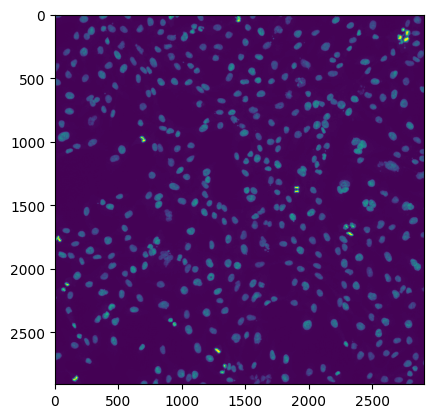

In [12]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei/train/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif')
print(im.shape)
plt.imshow(im)

## Check number of objects in nuclei mask

In [25]:
path = '/scr/yren/all_data_micronuclei/'
for row in range(metadata.shape[0]):
    imid = metadata.iloc[row]['filenames'].split('.')[0]
    micron_mask_path = path + metadata.iloc[row]['split'] + '/' + imid + '.phenotype_outlines.png'
    nuclei_mask_path = path + metadata.iloc[row]['split'] + '/' + imid + '.nuclei-clean.tif'
    
    micron_mask = skimage.io.imread(micron_mask_path)
    nuclei_mask = skimage.io.imread(nuclei_mask_path)
    
    nuclei_labels = skimage.morphology.label(nuclei_mask)
    print(len(np.unique(nuclei_labels)))
    
    if len(np.unique(nuclei_labels)) == 6:
        print(imid, metadata.iloc[row]['split'])
        

108
83
62
136
123
97
75
76
31
37
26
32
10
6
2023-05-31_misc-2 train
13
28
29
37
75
74
56
95
70
110
150
125
86
108
120
123
10
37
34
24
36
19
19
21
74
20
8
39
34
24
15
142
92
96
14
1633
14246
875
181
222
165
985
1364
651
1737
743
1240
1259
469
1425
1819
1441
906
468
1320
646
1391
793
1213
134
143
130
104
118
127
98
116
13
75
105
73
130
62
98
116
119
130
99
75
124
122
111
101
130
151
105
96
103
86
124
61
122
95
131
53
120
94
81
119
109
138
110
131
78
86
94
90
98
34
65
104
89
114
100
86
116
86
41
114
87
102
80
49
117
101
101
67
84
74
143
65
119
127
152
111
63
103
39
110
102
43
16
111
108
103
106
53
113
91
134
113
120
115
84
117
97
85
134
102
118
92
93
103
126
122
120
83
24
112
136
114
123
98
127
66
92
120
107
109
107
68
123
117
121
94
138
114
117
118
124
112
32
67
123
113
83
124
117
33
110
112
18
127
96
65
85
77
93
112
90
93
127
113
61
114
114
110
66
127
141
98
51
84
54
75
122
87
65
110
120
79
110
76
64
116
71
128
110
109
65
93
83
87
81
122
127
39
127
141
63
104


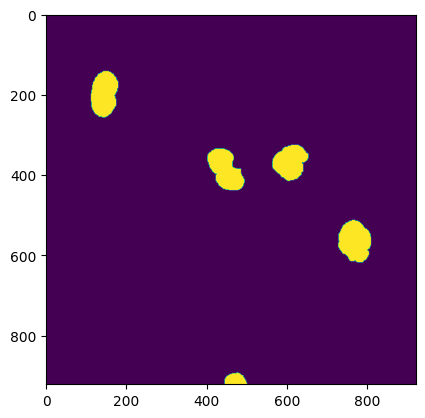

In [26]:
im = skimage.io.imread(path + 'train/' + '2023-05-31_misc-2.nuclei-clean.tif')
plt.imshow(im)

## Check number of objects in micronuclei mask

In [27]:
path = '/scr/yren/all_data_micronuclei/'
for row in range(metadata.shape[0]):
    imid = metadata.iloc[row]['filenames'].split('.')[0]
    micron_mask_path = path + metadata.iloc[row]['split'] + '/' + imid + '.phenotype_outlines.png'
    nuclei_mask_path = path + metadata.iloc[row]['split'] + '/' + imid + '.nuclei-clean.tif'
    
    micron_mask = skimage.io.imread(micron_mask_path)
    nuclei_mask = skimage.io.imread(nuclei_mask_path)
    
    micron_labels = skimage.morphology.label(micron_mask)
    print(len(np.unique(micron_labels)))

91
74
64
106
82
58
70
83
10
26
11
15
5
3
4
9
12
17
52
56
43
79
57
97
142
113
78
76
117
129
4
30
24
18
6
14
24
12
74
5
3
63
36
17
2
148
114
64
5
68
142
108
79
77
61
65
164
84
138
76
80
138
49
84
188
101
110
66
97
45
88
53
84
9
14
6
7
8
7
5
4
2
4
10
4
23
11
9
12
8
4
9
5
15
9
11
15
9
8
25
9
6
17
6
6
8
3
7
11
6
3
8
5
9
5
6
3
3
10
3
6
5
4
15
5
4
3
5
7
4
6
7
7
6
6
5
3
5
10
9
11
10
12
10
5
6
10
16
4
25
8
7
2
4
6
3
8
4
8
5
6
11
6
7
9
2
12
7
5
10
6
8
8
7
3
6
22
8
9
6
5
4
3
6
9
6
3
16
3
3
3
8
2
6
8
8
7
8
3
8
5
6
23
10
3
2
5
3
18
3
13
4
9
15
14
20
9
10
4
3
9
4
6
4
9
11
10
5
7
11
4
10
8
8
6
12
3
6
6
8
12
5
4
6
4
8
3
7
7
6
10
8
11
4
5
6
15
4
11
8
26
7
13
5
3


IXMtest_H11_s6_w19DF4E879-8DE4-45D6-840B-305BDDB27076


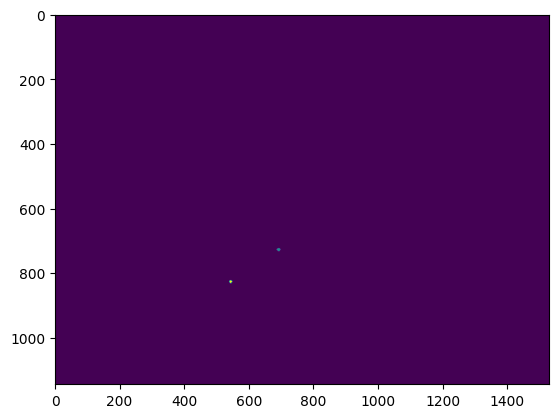

In [ ]:
print(imid)
plt.imshow(nuclei_mask)

# Create 3 histograms of micronuclei areas, colored per dataset among three splits

In [28]:
import os
import sys

import numpy as np
import pandas as pd
import skimage
import scipy

import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
split = ['train', 'validation', 'test']
path = '/scr/yren/all_data_micronuclei/'
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')

In [30]:
metadata.head()

,filenames,datasets,magnification,micron,split
0,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
1,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
2,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
3,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
4,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train


- create a new df for each folder

In [31]:
df_areas = pd.DataFrame(columns=['image_id', 'area', 'dataset'])
train_set = metadata[metadata.split == 'train']
path = '/scr/yren/all_data_micronuclei/train/'

for row in range(train_set.shape[0]):
    imid = train_set.iloc[row]['filenames'].split('.')[0]
    
    micron_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    labels = skimage.morphology.label(micron_mask)
    
    for i in range(1, len(np.unique(labels))):
        area = np.sum(labels == i)
        d = {'image_id':imid, 'area':area, 'dataset':train_set.iloc[row]['datasets']}
        df_areas = pd.concat([df_areas, pd.DataFrame([d])], ignore_index=True)

In [32]:
df_areas.to_csv('/scr/yren/all_data_micronuclei/train_area_distribution.csv', index=False)

In [33]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/train_area_distribution.csv')
df_areas

,image_id,area,dataset
0,2022-05-27_RPE1-3,44,mnfinder_train
1,2022-05-27_RPE1-3,111,mnfinder_train
2,2022-05-27_RPE1-3,36,mnfinder_train
3,2022-05-27_RPE1-3,95,mnfinder_train
4,2022-05-27_RPE1-3,12,mnfinder_train
...,...,...,...
3768,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,161,BBBC039
3769,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,56,BBBC039
3770,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,101,BBBC039
3771,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,64,BBBC039


In [34]:
df_areas[df_areas.area==1789]

,image_id,area,dataset
1852,C1-20X_c0_phalloidin_C3_Tile-18,1789,RPE1


(2910, 2910)


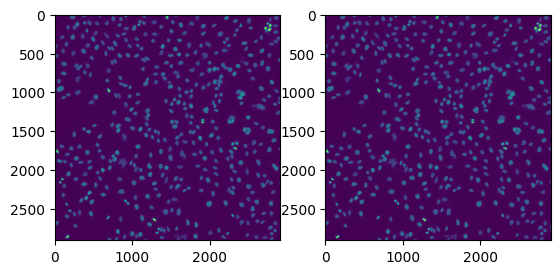

In [37]:
fig, ax = plt.subplots(1,2)
im = skimage.io.imread('/scr/yren/all_data_micronuclei/train/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif')
im2 = skimage.io.imread('/scr/yren/datasets/scale_aligned_dataset_v2_v3/C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif')
print(im.shape)
ax[0].imshow(im)
ax[1].imshow(im2)

- Train

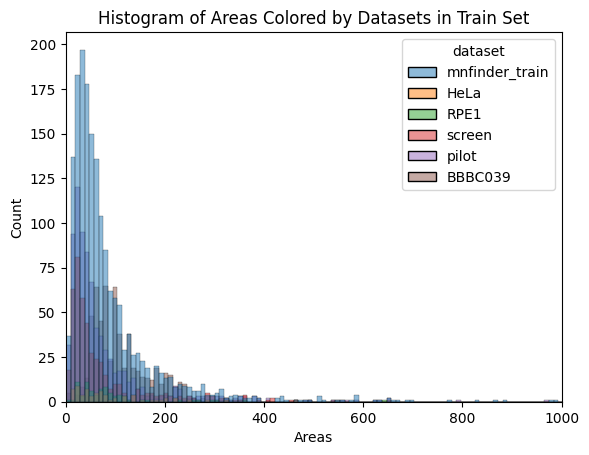

In [58]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/train_area_distribution.csv')
sns.histplot(data=df_areas, x='area', hue='dataset', kde=False, palette='tab10', multiple="layer")

plt.xlim([0,1000])
# plt.ylim([0,500])
plt.xlabel('Areas')
plt.ylabel('Count')
plt.title('Histogram of Areas Colored by Datasets in Train Set')
plt.show()

In [45]:
df_areas = pd.DataFrame(columns=['image_id', 'area', 'dataset'])
validation_set = metadata[metadata.split == 'validation']
path = '/scr/yren/all_data_micronuclei/validation/'

for row in range(validation_set.shape[0]):
    imid = validation_set.iloc[row]['filenames'].split('.')[0]
    
    micron_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    labels = skimage.morphology.label(micron_mask)
    
    for i in range(1, len(np.unique(labels))):
        area = np.sum(labels == i)
        d = {'image_id':imid, 'area':area, 'dataset':validation_set.iloc[row]['datasets']}
        df_areas = pd.concat([df_areas, pd.DataFrame([d])], ignore_index=True)
df_areas.to_csv('/scr/yren/all_data_micronuclei/validation_area_distribution.csv', index=False)

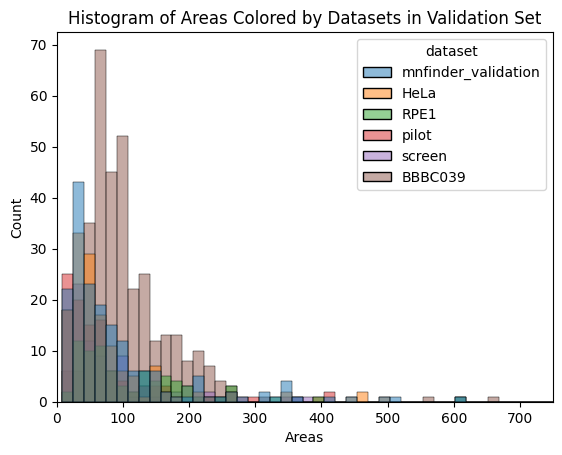

In [53]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/validation_area_distribution.csv')
sns.histplot(data=df_areas, x='area', hue='dataset', kde=False, palette='tab10', multiple="layer")

plt.xlim([0,750])
# plt.ylim([0,500])
plt.xlabel('Areas')
plt.ylabel('Count')
plt.title('Histogram of Areas Colored by Datasets in Validation Set')
plt.show()

In [47]:
df_areas = pd.DataFrame(columns=['image_id', 'area', 'dataset'])
test_set = metadata[metadata.split == 'test']
path = '/scr/yren/all_data_micronuclei/test/'

for row in range(test_set.shape[0]):
    imid = test_set.iloc[row]['filenames'].split('.')[0]
    
    micron_mask = skimage.io.imread(path + imid + '.phenotype_outlines.png')
    labels = skimage.morphology.label(micron_mask)
    
    for i in range(1, len(np.unique(labels))):
        area = np.sum(labels == i)
        d = {'image_id':imid, 'area':area, 'dataset':test_set.iloc[row]['datasets']}
        df_areas = pd.concat([df_areas, pd.DataFrame([d])], ignore_index=True)
df_areas.to_csv('/scr/yren/all_data_micronuclei/test_area_distribution.csv', index=False)

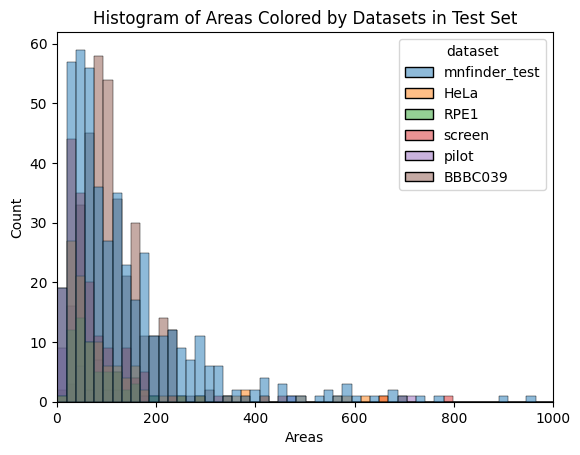

In [52]:
df_areas = pd.read_csv('/scr/yren/all_data_micronuclei/test_area_distribution.csv')
sns.histplot(data=df_areas, x='area', hue='dataset', kde=False, palette='tab10', multiple="layer")

plt.xlim([0,1000])
# plt.ylim([0,500])
plt.xlabel('Areas')
plt.ylabel('Count')
plt.title('Histogram of Areas Colored by Datasets in Test Set')
plt.show()